In [18]:
pip install soundfile simpleaudio librosa scipy matplotlib numpy sounddevice

In [26]:
import soundfile as sf

data, fs = sf.read("/content/self_recorded.wav")
info = sf.info("/content/self_recorded.wav")

print("Sampling Rate:", fs)
print("Bit Depth:", info.subtype)



Sampling Rate: 44100
Bit Depth: PCM_16


In [6]:
from IPython.display import Audio
import soundfile as sf

data, samplerate = sf.read("/content/LJ037-0171.wav")

Audio(data, rate=samplerate)

In [7]:
import soundfile as sf

data, fs = sf.read("/content/LJ037-0171.wav")
info = sf.info("/content/LJ037-0171.wav")

print("Sampling Rate:", fs)
print("Bit Depth:", info.subtype)


Sampling Rate: 22050
Bit Depth: PCM_16


Sample Rate (Hz): 22050
Total Samples: 167226
Total Duration (seconds): 7.583945578231292


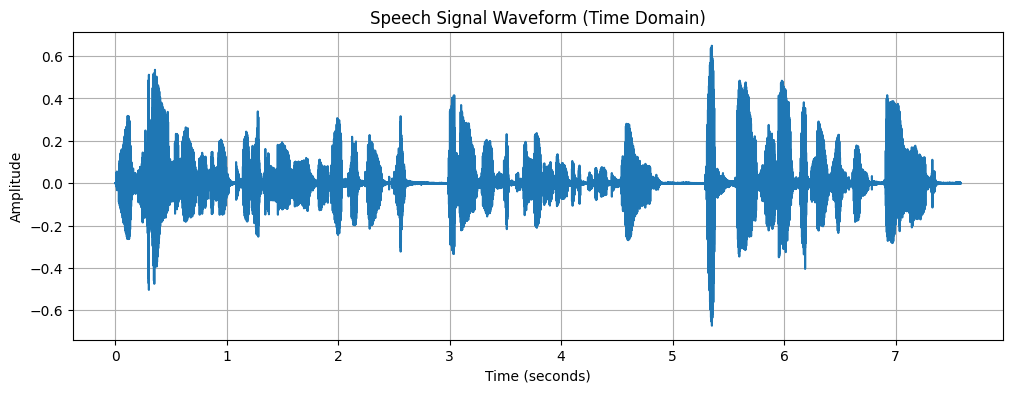

Active Speech Duration (seconds): 1.636281179138322


In [11]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt

signal, fs = sf.read("/content/LJ037-0171.wav")

if signal.ndim > 1:
    signal = signal.mean(axis=1)

num_samples = len(signal)
total_duration = num_samples / fs

print("Sample Rate (Hz):", fs)
print("Total Samples:", num_samples)
print("Total Duration (seconds):", total_duration)

time = np.arange(num_samples) / fs

plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Speech Signal Waveform (Time Domain)")
plt.grid(True)
plt.show()

frame_size = int(0.02 * fs)   # 20 ms
hop_size = int(0.01 * fs)     # 10 ms

energy = []
for i in range(0, num_samples - frame_size, hop_size):
    frame = signal[i:i + frame_size]
    energy.append(np.sum(frame ** 2))

energy = np.array(energy)

threshold = 0.1 * np.max(energy)

active_frames = energy > threshold
active_duration = np.sum(active_frames) * (hop_size / fs)

print("Active Speech Duration (seconds):", active_duration)

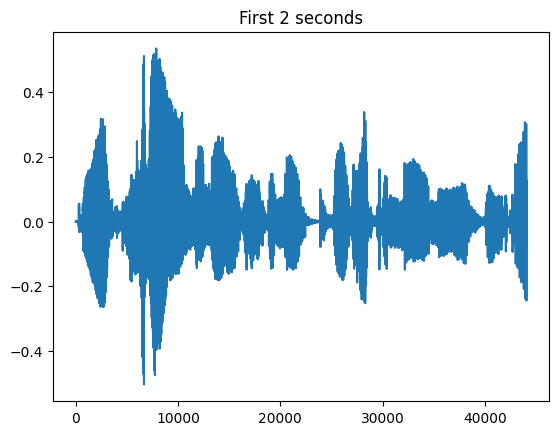

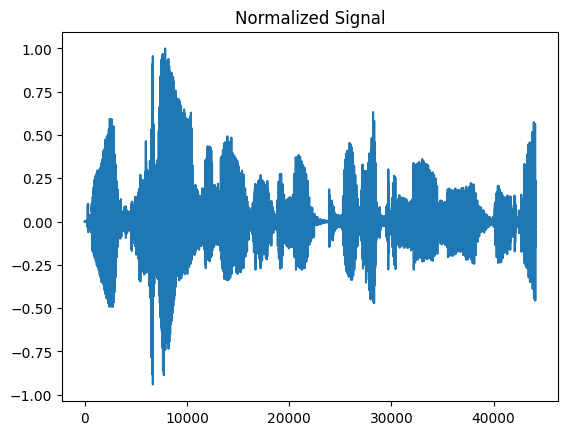

In [14]:
slice_signal = signal[:2*fs]

plt.plot(slice_signal)
plt.title("First 2 seconds")
plt.show()

normalized = slice_signal / np.max(np.abs(slice_signal))

plt.plot(normalized)
plt.title("Normalized Signal")
plt.show()

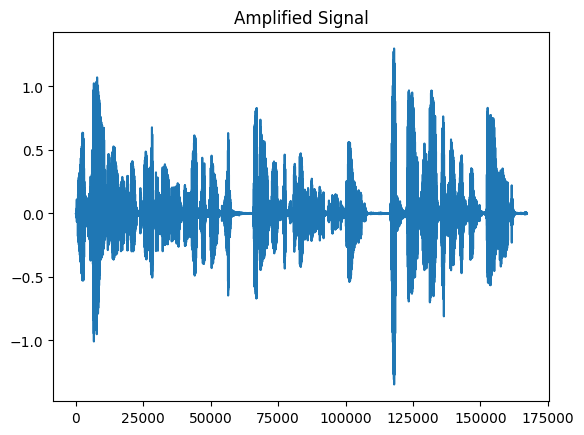

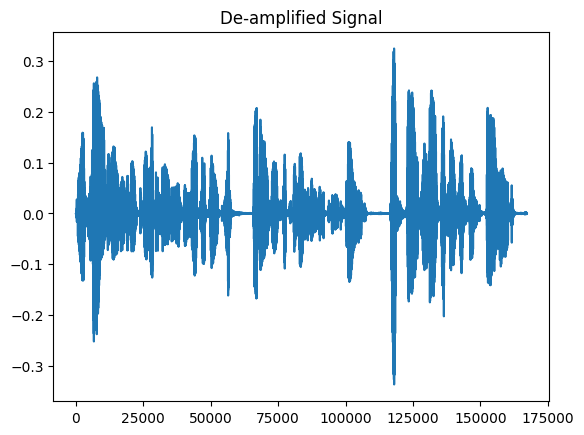

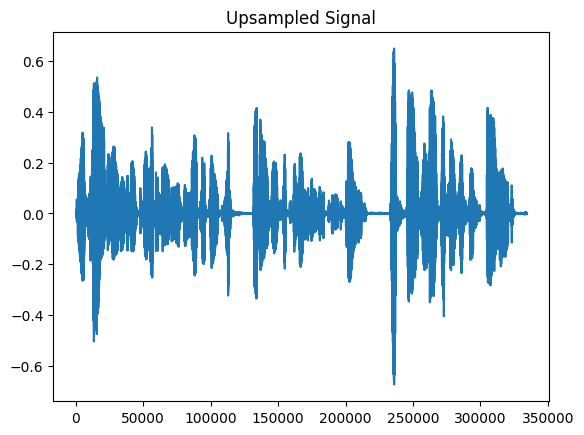

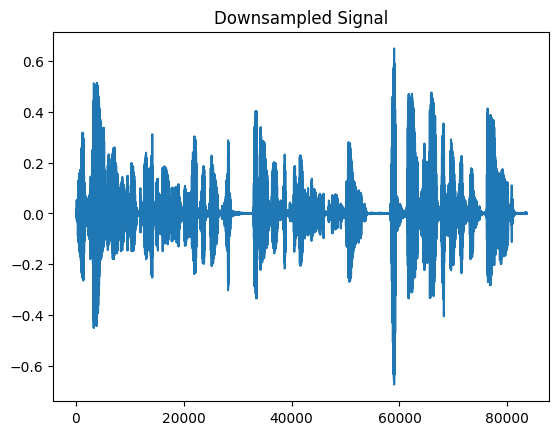

In [15]:
amplified = signal * 2
deamplified = signal * 0.5

plt.plot(amplified)
plt.title("Amplified Signal")
plt.show()

plt.plot(deamplified)
plt.title("De-amplified Signal")
plt.show()

upsampled = np.repeat(signal, 2)
downsampled = signal[::2]

plt.plot(upsampled)
plt.title("Upsampled Signal")
plt.show()

plt.plot(downsampled)
plt.title("Downsampled Signal")
plt.show()


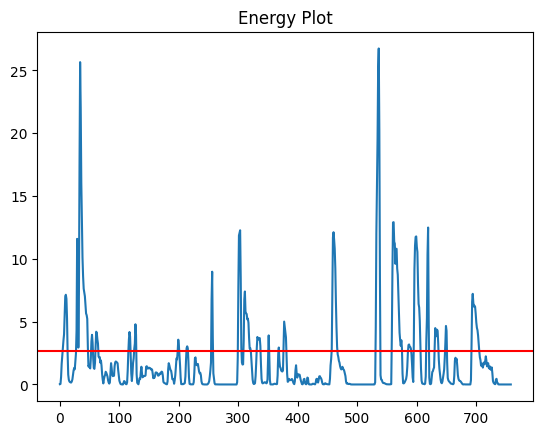

In [16]:
plt.plot(energy)
plt.axhline(y=threshold, color='r')
plt.title("Energy Plot")
plt.show()
